# Retail Sales Performance Analysis

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the cleaned retail sales dataset to identify trends, patterns, and business insights. The analysis focuses on sales performance, profitability, customer behavior, product performance, and regional trends to support data-driven decision-making.

In [4]:
%pip install seaborn
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: C:\Users\morte\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
data_path = Path("../data/cleaned/cleaned_retail_sales.csv")

df = pd.read_csv(data_path)

# Dataset Overview

In [9]:
df.head()
df.info()
df.describe()
df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   row_id                    9994 non-null   int64  
 1   order_id                  9994 non-null   object 
 2   order_date                9994 non-null   object 
 3   ship_date                 9994 non-null   object 
 4   ship_mode                 9994 non-null   object 
 5   customer_id               9994 non-null   object 
 6   customer_name             9994 non-null   object 
 7   segment                   9994 non-null   object 
 8   country                   9994 non-null   object 
 9   city                      9994 non-null   object 
 10  state                     9994 non-null   object 
 11  postal_code               9994 non-null   int64  
 12  region                    9994 non-null   object 
 13  product_id                9994 non-null   object 
 14  category

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub_category,product_name,order_month,order_year_month,profit_status
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850,12,48,3
top,CA-2017-100111,2016-09-05,2015-12-16,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,November,2017-12,Profitable
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48,1471,462,8058


In [10]:
# Overall Business Performance 
total_sales = df["sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

total_profit = df["profit"].sum()
print(f"Total Profit: ${total_profit:,.2f}")

total_orders = df["order_id"].nunique()
print(f"Total Orders: {total_orders:,}")

total_customers = df["customer_id"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793


# Sales Distribution

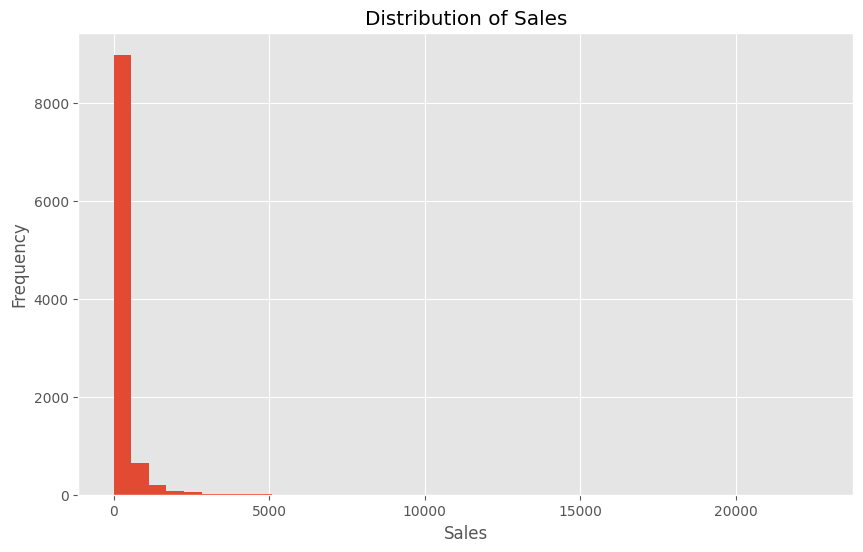

In [11]:
plt.figure(figsize=(10,6))

plt.hist(df["sales"], bins=40)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

## Are most sales small or large?
Most customer transactions have relatively low sales values, indicating that the business processes a high volume of small orders rather than a few expensive purchases.
## Are there outliers?
A few transactions have exceptionally high sales values compared to the rest of the dataset. These represent high-value orders and should be retained because they are likely to be legitimate business transactions rather than data-entry errors.
## Is the distribution skewed?
Yes, the distribution is positively (right) skewed. The sales distribution is highly right-skewed. This suggests that while most sales are relatively small, a limited number of large transactions contribute significantly to total revenue.

## Business Insight
The company's revenue appears to be driven by many low-value transactions along with a relatively small number of high-value orders. Because these large orders contribute disproportionately to total sales, retaining key customers responsible for these purchases could have a significant impact on overall revenue.

# Category Performance

In [17]:
##Which category sells the most?
category_sales = (
    df
    .groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales


category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

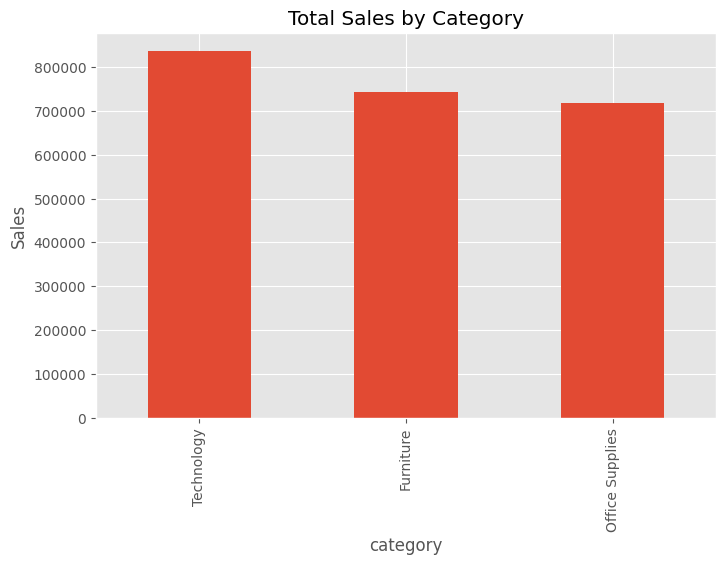

In [18]:
category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Sales by Category")

plt.ylabel("Sales")

plt.show()

In [19]:
##Which category generates the highest profit?
category_profit = (
    df
    .groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

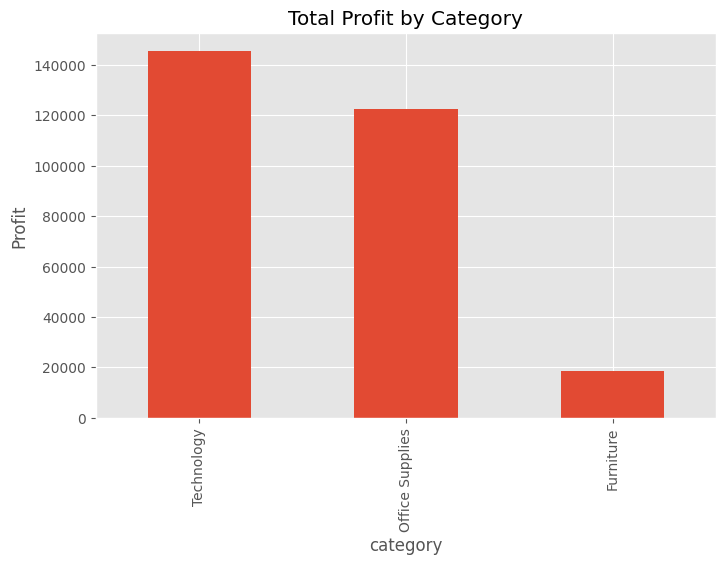

In [20]:
category_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Profit by Category")

plt.ylabel("Profit")

plt.show()

# Subcategory Analysis

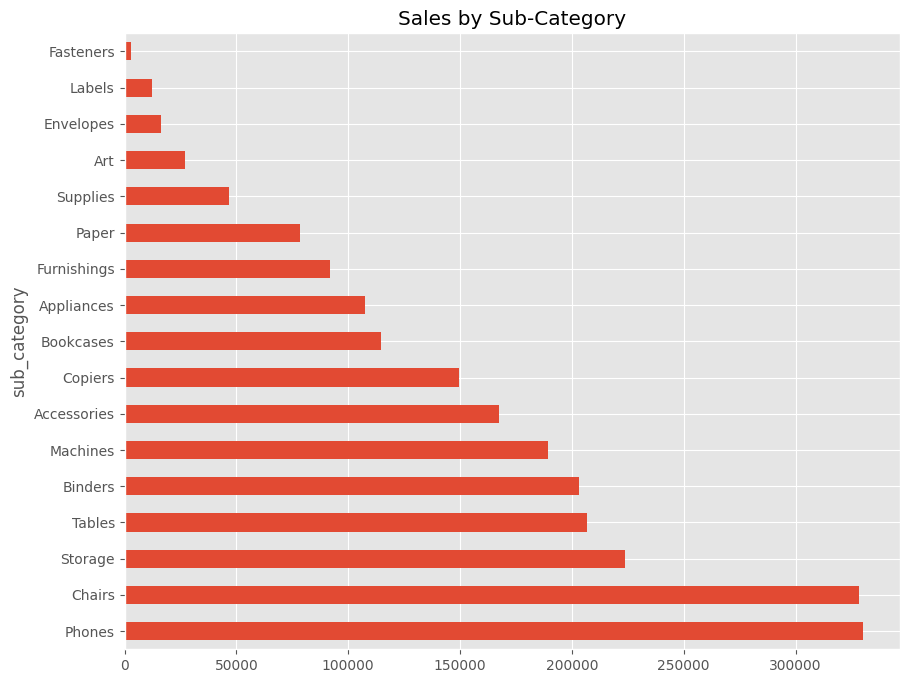

In [22]:
subcategory_sales = (
    df
    .groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
)


subcategory_sales.plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Sales by Sub-Category")

plt.show()

# Regional Performance

In [24]:
region_sales = (
    df
    .groupby("region")["sales"]
    .sum()
)

region_sales

region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: sales, dtype: float64

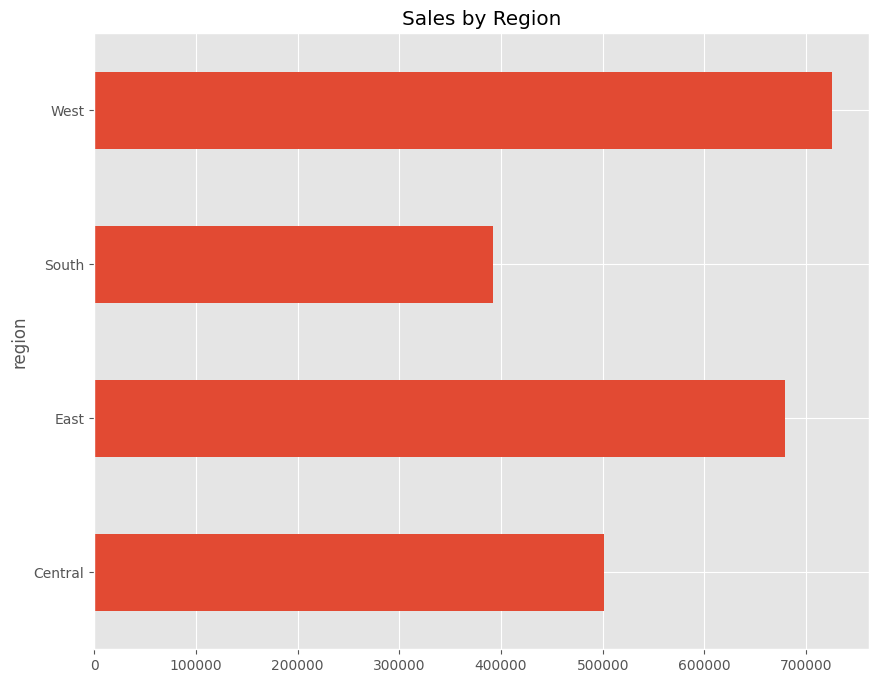

In [25]:
region_sales.plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Sales by Region")

plt.show()

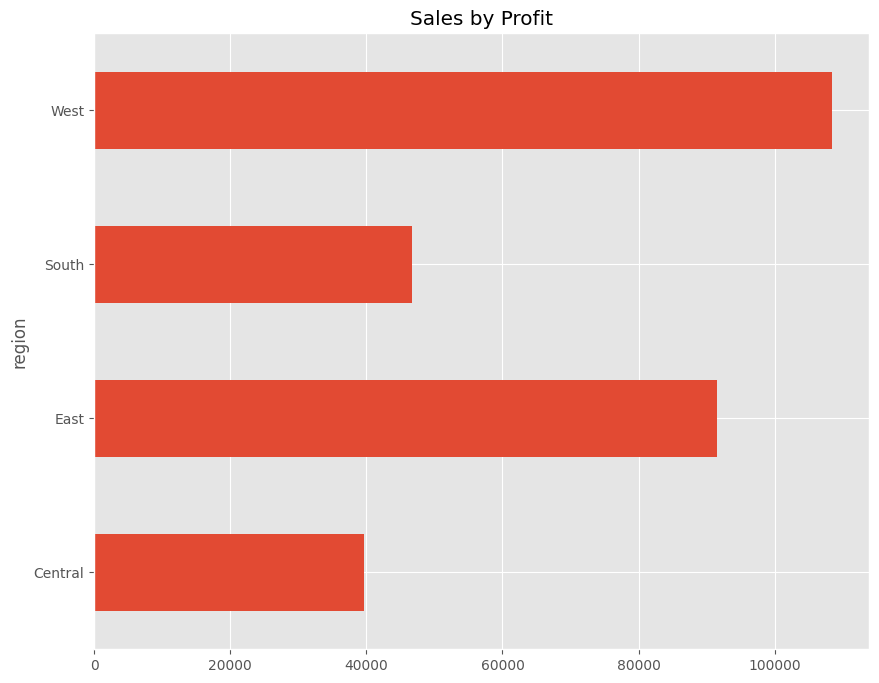

In [27]:
region_profit = (
    df
    .groupby("region")["profit"]
    .sum()
)

region_profit.plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Sales by Profit")

plt.show()

In [ ]:
# West performs best
#Central region is least profitable

# Customer Analysis

In [28]:
top_customers = (
    df
    .groupby("customer_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

In [ ]:
#Sean Miller is our most valuable customer

# Product Analysis

In [29]:
top_products = (
    df
    .groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

In [ ]:
# Canon imageCLASS 2200 Advanced Copier is the most populor product

# Monthly Sales 

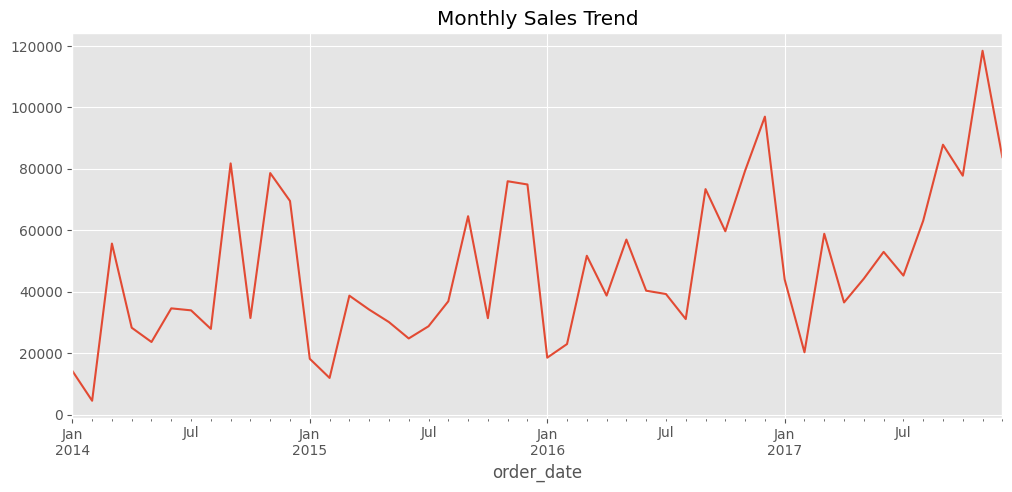

In [31]:
#First we convert dates
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_sales = (
    df
    .groupby(df["order_date"].dt.to_period("M"))
    ["sales"]
    .sum()
)

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")

plt.show()

# Discount vs Profit

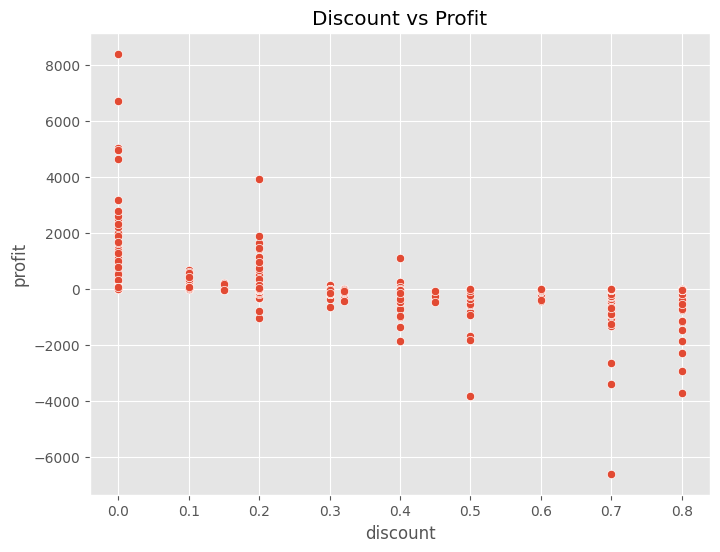

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit"
)

plt.title("Discount vs Profit")

plt.show()

## Does offering larger discounts increase or decrease profit?
####  1. Most highly profitable orders received little or no discount. 
Look at the left side of the chart.
At 0% discount, many orders generated high profits, including some exceeding $8,000.
####  2. As discounts increase, profits generally decrease.
Notice the overall trend:
- Discount = 0.0 → mostly positive profits
- Discount = 0.2 → profits become more variable
- Discount = 0.4–0.8 → many transactions fall below zero

This suggests a negative relationship between discount and profit.
#### 3. There is considerable variation.
Even with the same discount level, profits vary widely.
For example, at 20% discount, some transactions earn over $3,000, while others lose money.
This means discount alone does not determine profit. Other factors—such as product category, cost, quantity, or customer segment—also influence profitability.

# Business Insights
1. The company earns its highest profits from orders with little or no discount.
2. Higher discounts are associated with lower profitability, particularly discounts of 50% or more.
3. Discounts above 60–70% frequently produce financial losses.
4. Since some discounted orders remain profitable, the company should investigate which products or customer segments perform well under moderate discounts.

# Business Recommendations
#### Recommendation 1
Review the current discount strategy and avoid offering excessive discounts unless they support a specific business objective.

#### Recommendation 2
Investigate products that remain profitable despite discounts and use them in future promotional campaigns.

#### Recommendation 3
Implement approval rules for discounts above 50% to reduce the risk of large financial losses.

#### Recommendation 4
Conduct further analysis by product category and customer segment to identify where discounts are most effective.

# Correlation Matrix

In [33]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

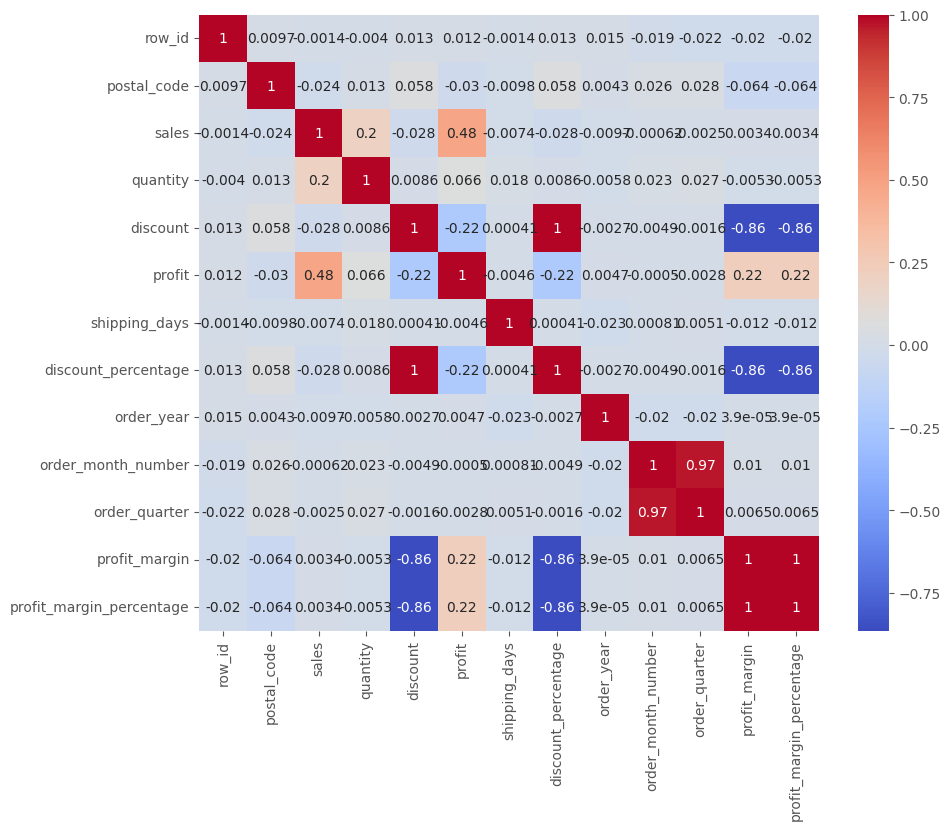

In [34]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Business Insights

#### Insight 1
Technology generated the highest revenue and profit, indicating it is the company's strongest product category.

#### Insight 2
Several high-discount transactions resulted in negative profit, suggesting discount policies should be reviewed.

#### Insight 3
The West region consistently outperformed the other regions.

#### Insight 4
A relatively small group of customers accounted for a significant portion of total sales.

# Recommendations
- Reduce discounts above 30%.
- Increase inventory for Technology products.
- Expand marketing efforts in high-performing regions.
- Develop customer loyalty programs targeting top customers.